In [ ]:
# %load test_gdal.py
from osgeo import gdal
from error_deal import catch_error 

filename ="D:/pyLearn/test_project/data/tif/resultData_withoutSea.tif"

gdal.UseExceptions()
try:
    dataset = gdal.Open(filename, gdal.GA_ReadOnly)
except Exception as e:
    print(f"Error opening dataset.Error message: {e} !")

### 1. 错误处理示例 ###
# gdal.UseExceptions()
# try:
#     dataset = gdal.Open("non_existent_file.tif", gdal.GA_ReadOnly)
# except Exception as e:
#     print(f"Error opening dataset.Error message: {e} !")

# gdal.PushErrorHandler(catch_error.gdal_error_handler)
# gdal.Open("non_existent_file.tif", gdal.GA_ReadOnly)
# gdal.PopErrorHandler()

# print("Finished error handling test.")


### 2. 读取数据元数据 ###
gdal.PushErrorHandler(catch_error.gdal_error_handler)
adfGeoTransform = dataset.GetGeoTransform()
print("GeoTransform: ", adfGeoTransform) # 输出地理变换参数
"""
GeoTransform 对应关系如下：
adfGeoTransform[0] = top left x (左上角x坐标)
adfGeoTransform[1] = w-e pixel resolution (像素宽度)
adfGeoTransform[2] = rotation, 0 if image is "north up" (旋转，0表示图像是“北向上”)
adfGeoTransform[3] = top left y (左上角y坐标)
adfGeoTransform[4] = rotation, 0 if image is "north up" (旋转，0表示图像是“北向上”)
adfGeoTransform[5] = n-s pixel resolution (像素高度，通常为负值)

"""
gdal.PopErrorHandler()

GeoTransform:  (-118.60708333, 0.000277777779930051, 0.0, 34.317638854, 0.0, -0.0002777777799389788)


In [5]:
print("Driver: {}/{}".format(dataset.GetDriver().ShortName,
                            dataset.GetDriver().LongName))
print("Size is {} x {} x {}".format(dataset.RasterXSize,
                                    dataset.RasterYSize,
                                    dataset.RasterCount))
print("Projection is {}".format(dataset.GetProjection()))
geotransform = dataset.GetGeoTransform()
if geotransform:
    print("Origin = ({}, {})".format(geotransform[0], geotransform[3]))
    print("Pixel Size = ({}, {})".format(geotransform[1], geotransform[5]))

Driver: GTiff/GeoTIFF
Size is 3717 x 2622 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-118.60708333, 34.317638854)
Pixel Size = (0.000277777779930051, -0.0002777777799389788)


In [6]:
print(type(dataset))

<class 'osgeo.gdal.Dataset'>


In [7]:
##元数据读取函数##
def getDatasetInfo (dataset):
  print("Driver: {}/{}".format(dataset.GetDriver().ShortName,
                            dataset.GetDriver().LongName))
  print("Size is {} x {} x {}".format(dataset.RasterXSize,
                                    dataset.RasterYSize,
                                    dataset.RasterCount))
  print("Projection is {}".format(dataset.GetProjection()))
  geotransform = dataset.GetGeoTransform()
  if geotransform:
      print("Origin = ({}, {})".format(geotransform[0], geotransform[3]))
      print("Pixel Size = ({}, {})".format(geotransform[1], geotransform[5]))
      data_info = {'Driver': '{}/{}'.format(dataset.GetDriver().ShortName,
                              dataset.GetDriver().LongName),
                   'Size': (dataset.RasterXSize, dataset.RasterYSize, dataset.RasterCount),  # xsize, ysize, bands
                   'Projection':dataset.GetProjection(),
                   'Origin':(geotransform[0], geotransform[3]),
                   'Pixel Size':(geotransform[1], geotransform[5])}
  else:
      data_info = {'Driver': '{}/{}'.format(dataset.GetDriver().ShortName,
                              dataset.GetDriver().LongName),
                   'Size': (dataset.RasterXSize, dataset.RasterYSize, dataset.RasterCount),  # xsize, ysize, bands
                   'Projection':dataset.GetProjection(),
                   'Origin': None,
                   'Pixel Size': None}
  return data_info   

In [ ]:
getDatasetInfo(dataset)

Driver: GTiff/GeoTIFF
Size is 3717 x 2622 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-118.60708333, 34.317638854)
Pixel Size = (0.000277777779930051, -0.0002777777799389788)


{'Driver': 'GTiff/GeoTIFF',
 'Size': (3717, 2622, 1),
 'Projection': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]',
 'Origin': (-118.60708333, 34.317638854),
 'Pixel Size': (0.000277777779930051, -0.0002777777799389788)}

In [9]:
data_info=getDatasetInfo(dataset)

Driver: GTiff/GeoTIFF
Size is 3717 x 2622 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-118.60708333, 34.317638854)
Pixel Size = (0.000277777779930051, -0.0002777777799389788)


In [10]:
print(data_info)

{'Driver': 'GTiff/GeoTIFF', 'Size': (3717, 2622, 1), 'Projection': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]', 'Origin': (-118.60708333, 34.317638854), 'Pixel Size': (0.000277777779930051, -0.0002777777799389788)}


In [ ]:
from toolbox import readData
data_info = readData.get_dataset_info(dataset)

Driver: GTiff/GeoTIFF
Size is 3717 x 2622 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-118.60708333, 34.317638854)
Pixel Size = (0.000277777779930051, -0.0002777777799389788)


In [3]:
### 3. 读取数据波段信息测试
band = dataset.GetRasterBand(1)
print("Band Type={}".format(gdal.GetDataTypeName(band.DataType)))

min = band.GetMinimum()
max = band.GetMaximum()
if not min or not max:
    (min,max) = band.ComputeRasterMinMax(True)
print("Min={:.3f}, Max={:.3f}".format(min,max))

if band.GetOverviewCount() > 0:
    print("Band has {} overviews".format(band.GetOverviewCount()))

if band.GetRasterColorTable():
    print("Band has a color table with {} entries".format(band.GetRasterColorTable().GetCount()))

Band Type=Float32
Min=-37.621, Max=23.013


In [4]:
### 4. 读取波段对象数据值测试 ###
scanline = band.ReadRaster(xoff=0, yoff=0,
                        xsize=band.XSize, ysize=1,
                        buf_xsize=band.XSize, buf_ysize=1,
                        buf_type=gdal.GDT_Float32)

In [5]:
print(scanline)

bytearray(b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00R\x01\x87\xc0\xd4DR\xc0nV\x8a\xbf\xc3\xfbU\xbf\x89\xd5\xd3\xbf\x01,\x16\xc0\x1dC3\xc0\xfcFz\xc0\xad,\x8c\xc0\xd2\xce\x88\xc00H\x97\xc0S\xa3\xbe\xc0\xb7m\xf3\xc0\x18\xaa&\xc1\t\x174\xc1\xfa\x17\xd2\xc0!G\xf8?\x8cb\x97?\x7fw\x19\xc0\x1f\x15\xa1\xc0\x97\xd2\x9c\xc0\xcd\xc5\x84\xc04@\xd1\xc0\xf6\x1f\x9f\xc0\xf9\xdd4\xc0\xc9\xeee\xc0\x83\xf86\xbfg\x07\xae@j\xf5\x99@_b)\xc0\x03\xfcz\xc0\x92(\x13?t\x05-\xc0+v\x01\xc0?H\x97\xbfe$l\xc0\xf3\xfc\xf2\xc0M`H\xc0\x96YP\xc0\x8f\xda\x89\xbe\xc7\xc5o\xc0\xbe/\xfb\xbf&\x14z\xc0H\x82\xdf\xc0\xea\x07\xd9\xc0\'(\x80\xc0\

In [6]:
print(type(scanline))

<class 'bytearray'>


In [7]:
import struct
tuple_of_floats = struct.unpack('f' * band.XSize, scanline)

In [8]:
print(tuple_of_floats)

(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -4.218911170959473, -3.2854509353637695, -1.0807626247406006, -0.8358728289604187, -1.6549540758132935, -2.346435785293579, -2.800971269607544, -3.9105825424194336, -4.380453586578369, -4.275246620178223, -4.727561950683594, -5.957437038421631, -7.607142925262451, -10.416526794433594, -11.255623817443848, -6.565426826477051, 1.9396706819534302, 1.182694911956787, -2.397918462753296, -5.033828258514404, -4.900706768035889, -4.149145603179932, -6.539087295532227, -4.972651481628418, -2.8260481357574463, -3.5926992893218994, -0.7147294878959656, 5.438403606414795, 4.8112077713012695, -2.6466290950775146, -3.9216315746307373, 0.5748378038406372, -2.703457832336426, -2.0228374004364014, -1.1818922758102417, -3.6897213459014893, -7.593377590179443, -3.130877733230591, -3.2554678916931152, -0.26924559473991394, -3.746446371078491, -1.9623944759368896, -3.9074

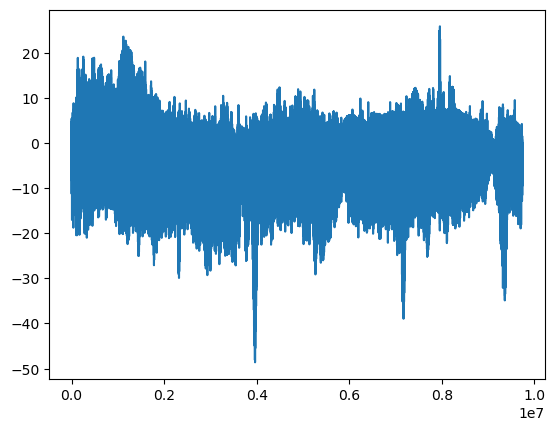

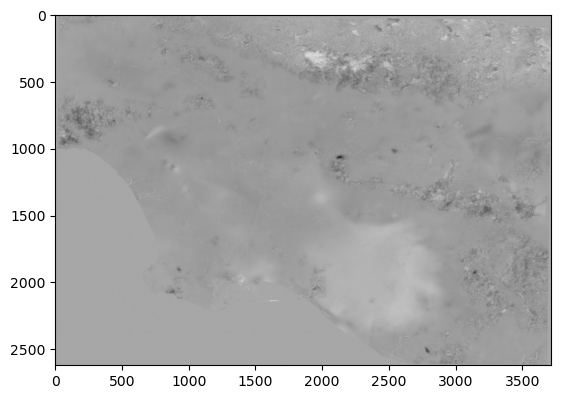

In [18]:
### 4. 读取波段对象数据值测试 ###
# 读取结果为一个字节字符串，长度为XSize*YSize*4（每个像素值占4字节，因为是32位浮点数），需要使用struct模块将其解包成一个浮点数元组，每个元素对应一个像素值
scanline = band.ReadRaster(xoff=0, yoff=0,
                        xsize=band.XSize, ysize=band.YSize,
                        buf_xsize=band.XSize, buf_ysize=band.YSize,
                        buf_type=gdal.GDT_Float32)

import struct
# 解包后为一个包含所有像素值的浮点数元组，长度为XSize*YSize，之后若需要展示为二维数组，可以使用numpy进行重塑
tuple_of_floats = struct.unpack('f' * band.XSize * band.YSize, scanline) # 将字节数据解包成浮点数元组，'f'表示每个元素是一个32位浮点数，乘以XSize*YSize表示有多少个元素
import numpy as np
numpy_array = np.array(tuple_of_floats).reshape((band.YSize, band.XSize)) # 将一维的像素值元组重塑为二维数组，行数为YSize，列数为XSize
#展示读取到的band影像
import matplotlib.pyplot as pyplot
pyplot.plot(tuple_of_floats)
pyplot.show()
pyplot.imshow(numpy_array, cmap='gray')

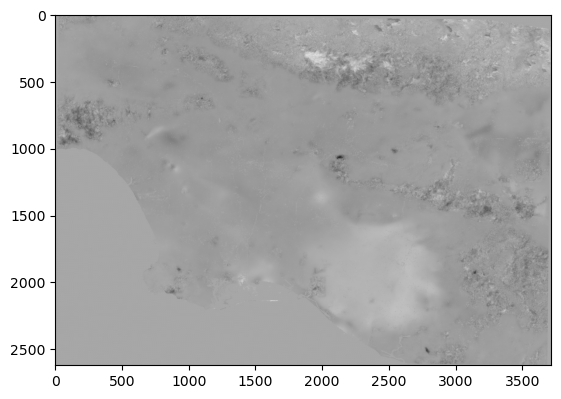

In [21]:
band=dataset.GetRasterBand(1)
array = band.ReadAsArray()
array = array.reshape((band.YSize, band.XSize))
import matplotlib.pyplot as plt 
plt.imshow(array, cmap='gray')

In [3]:
### 6. 拷贝数据文件 ###
# 使用GDAL驱动创建一个新的数据集，并将原数据集的内容复制到新数据集中，参数strict=0表示在复制过程中允许某些不兼容的选项被忽略，
# options参数可以指定一些创建选项，例如TILED=YES表示创建一个分块的tif文件，COMPRESS=PACKBITS表示使用PackBits压缩算法来压缩数据以节省存储空间
src_filename = "D:/pyLearn/test_project/data/tif/resultData_withoutSea.tif"
dst_filename = "D:/pyLearn/test_project/data/tif/resultData_withoutSea_copy.tif"
driver = gdal.GetDriverByName('GTiff') # 获取GTiff驱动对象，GTiff是GDAL支持的一个常见的栅格数据格式，代表GeoTIFF格式，可以处理地理空间信息的TIFF文件
src_ds = gdal.Open(src_filename)
dst_ds = driver.CreateCopy(dst_filename, src_ds, strict=0,
                        options=["TILED=YES", "COMPRESS=PACKBITS"])

# Once we're done, close properly the dataset
dst_ds = None
src_ds = None 

d:\pytorch\envs\pyGeoLearn\Lib\site-packages\osgeo\gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


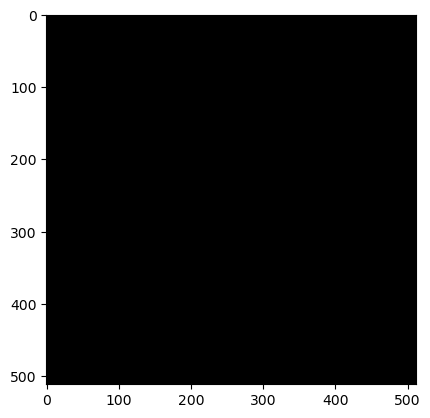

In [32]:
with gdal.Open(dst_filename) as dst_ds:
    band = dst_ds.GetRasterBand(1)
    array = band.ReadAsArray()
    array = array.reshape((band.YSize, band.XSize)) # 将一维的像素值数组重塑为二维数组，行数为YSize，列数为XSize
    import matplotlib.pyplot as plt
    plt.imshow(array, cmap='gray')
      # 这里可以添加一些对dst_ds的操作，例如设置元数据等

In [5]:
### 7. 创建指定类型空白文件
dst_ds = driver.Create(dst_filename, xsize=512, ysize=512,
                    bands=1, eType=gdal.GDT_Byte)
from osgeo import osr
import numpy
dst_ds.SetGeoTransform([444720, 30, 0, 3751320, 0, -30]) # 设置地理变换参数，参数是一个包含6个元素的列表，分别对应于左上角x坐标、像素宽度、旋转、左上角y坐标、旋转和像素高度
srs = osr.SpatialReference() # 创建一个空间参考对象
srs.SetUTM(11, 1)
srs.SetWellKnownGeogCS("NAD27")
dst_ds.SetProjection(srs.ExportToWkt()) # 设置投影信息，使用WKT格式，ExportToWkt()方法将空间参考对象转换为WKT字符串
raster = numpy.zeros((512, 512), dtype=numpy.uint8)
dst_ds.GetRasterBand(1).WriteArray(raster) # 将numpy数组写入波段对象，WriteArray()方法将数组数据写入到波段中，参数raster是一个512x512的二维数组，数据类型为uint8（无符号8位整数），表示每个像素值的范围是0-255
# Once we're done, close properly the dataset
dst_ds = None

In [ ]:
### 8. 读取拷贝文件的元数据测试 ###
from osgeo import gdal
dst_ds= gdal.Open(dst_filename)
from toolbox import get_dataset_info
data_info = get_dataset_info(dst_ds)
dst_ds = None
print(data_info)

Driver: GTiff/GeoTIFF
Size: 512 x 512 x 1
Projection: PROJCS["NAD27 / UTM zone 11N",GEOGCS["NAD27",DATUM["North_American_Datum_1927",SPHEROID["Clarke 1866",6378206.4,294.978698213898,AUTHORITY["EPSG","7008"]],AUTHORITY["EPSG","6267"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4267"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26711"]]
Pixel Size: (30.0, -30.0)
Origin: (444720.0, 3751320.0)
{'Driver': 'GTiff/GeoTIFF', 'Size': (512, 512, 1), 'Projection': 'PROJCS["NAD27 / UTM zone 11N",GEOGCS["NAD27",DATUM["North_American_Datum_1927",SPHEROID["Clarke 1866",6378206.4,294.978698213898,AUTHORITY["EPSG","7008"]],AUTHORITY["EPSG","6267"]],PRIMEM["Greenwich"